In [41]:
!pip install tensorflow

In [42]:
# Importing the libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [43]:
num_words = 10_000  # keep the 10k most frequent tokens


In [44]:
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

In [45]:
train_data.shape, test_data.shape

((25000,), (25000,))

In [46]:
train_labels.shape, test_labels.shape

((25000,), (25000,))

In [47]:
# Fonction de vectorisation (one-hot encoding)
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  #set specific indices of results[i] to 1s
    return results

In [48]:
# Conversion des séquences en matrices binaires
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [49]:
#Normalisation des images pour conserver l'essentielle
y_train = np.array(train_labels).astype('float32')
y_test = np.array(test_labels).astype('float32')

In [50]:
y_train, y_test

(array([1., 0., 0., ..., 0., 1., 0.], dtype=float32),
 array([0., 1., 1., ..., 0., 0., 0.], dtype=float32))

In [51]:
# Création d'un ensemble de validation
x_val = x_train[:10000]
p_x_train = x_train[10000:]

In [52]:
y_val = y_train[:10000]
p_y_train = y_train[10000:]

In [53]:
print(x_val.shape, p_x_train.shape)
print(y_val.shape, p_y_train.shape)

(10000, 10000) (15000, 10000)
(10000,) (15000,)


In [54]:
print("Ensemble d'entraînement :", p_x_train.shape)
print("Ensemble de validation :", x_val.shape)
print("Ensemble de test :", x_test.shape)

Ensemble d'entraînement : (15000, 10000)
Ensemble de validation : (10000, 10000)
Ensemble de test : (25000, 10000)


## **2. Construction du modèle**

In [55]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(10000,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

Notre reseau comporte 160305 paramètres

## **

In [57]:
history = model.fit(p_x_train, p_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7707 - loss: 0.5464 - val_accuracy: 0.8630 - val_loss: 0.4104
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8883 - loss: 0.3374 - val_accuracy: 0.8822 - val_loss: 0.3200
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9192 - loss: 0.2502 - val_accuracy: 0.8899 - val_loss: 0.2866
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9331 - loss: 0.2036 - val_accuracy: 0.8891 - val_loss: 0.2771
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9453 - loss: 0.1704 - val_accuracy: 0.8871 - val_loss: 0.2800
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9515 - loss: 0.1467 - val_accuracy: 0.8758 - val_loss: 0.3234
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9609 - loss: 0.1262 - val_accuracy: 0.8836 - val_loss: 0.2928
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9663 - loss: 0.1100 - val_accuracy: 0.8828 - v

In [58]:
loss, accuracy = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8589 - loss: 0.5831


In [59]:
print('Test loss:', round(loss, 2))
print('Test accuracy:', round(accuracy,2))

Test loss: 0.58
Test accuracy: 0.86


Notre modèle à un accuracy de 84%, il arrive à faire de prédiction correcte et minimise les pertes, ici on a une perte de 0.78

## **4. Evaluate the Model:**

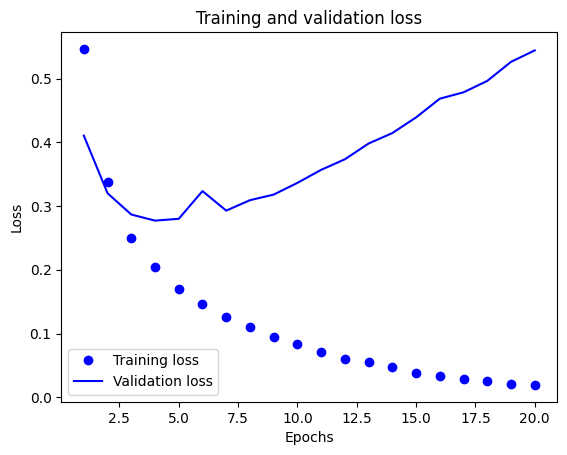

In [60]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

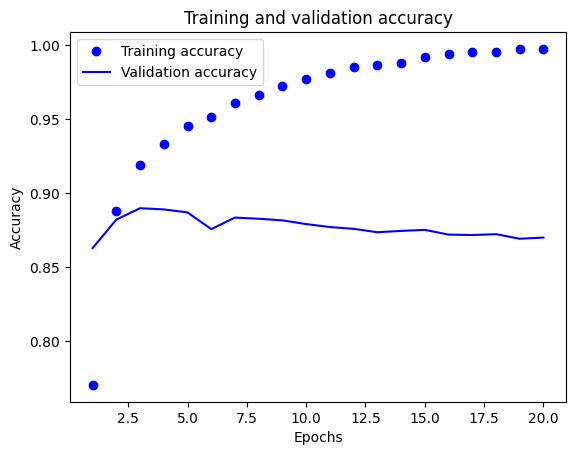

In [62]:
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Les courbes de perte et de précision montrent un phénomène de surapprentissage. La perte de validation atteint son minimum vers les époques 4 à 5 puis augmente, tandis que la perte d'entraînement continue de diminuer. De même, la précision d'entraînement continue de croître jusqu'à près de 100 %, alors que la précision de validation plafonne autour de 89 %. Cela indique que le modèle commence à mémoriser les données d'entraînement plutôt qu'à apprendre des motifs généralisables. L'époque optimale se situe donc autour de la 4ᵉ ou 5ᵉ itération.

In [65]:
# Réentraînement avec le nombre optimal d'époques
history = model.fit(
    p_x_train,
    p_y_train,
    epochs=5,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.9999 - loss: 0.0062 - val_accuracy: 0.8680 - val_loss: 0.6495
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9988 - loss: 0.0085 - val_accuracy: 0.8688 - val_loss: 0.6651
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9983 - loss: 0.0084 - val_accuracy: 0.8674 - val_loss: 0.6891
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9999 - loss: 0.0041 - val_accuracy: 0.8664 - val_loss: 0.7081
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9984 - loss: 0.0076 - val_accuracy: 0.8675 - val_loss: 0.7303


In [66]:
# Évaluation sur l'ensemble de test
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss :", round(loss,2))
print("Test Accuracy :", round(accuracy,2))

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8552 - loss: 0.7820
Test Loss : 0.78
Test Accuracy : 0.86


Le modèle a atteint sa performance maximale, mais avec une époque de 5, les pertes augmentent

## **5. Analyze Results**

### **Observations**
La précision d'entraînement est presque parfaite (≈ 99,8 % à 100 %).
La perte d'entraînement est extrêmement faible (proche de 0).
En revanche, la précision de validation reste autour de 86-87 % sans amélioration notable.
La perte de validation augmente progressivement de 0.65 à 0.73.

Ces résultats indiquent que le modèle surapprend (overfitting) : il mémorise très bien les données d'entraînement mais généralise moins bien sur des données jamais vues. L'écart important entre les performances d'entraînement et de validation en est la preuve.

**Résultats finaux sur l'ensemble de test**

Après évaluation sur les données de test :

* Perte (Test Loss) : 0.78
* Précision (Test Accuracy) : 0.86 (86 %)
**Conclusion**

Le modèle obtient une précision quasi parfaite sur les données d'entraînement, mais seulement 86 % sur les données de validation et de test. La hausse continue de la perte de validation montre un phénomène de surapprentissage. Malgré cela, le modèle conserve une bonne capacité de classification avec une précision finale de 86 % sur l'ensemble de test et une perte de 0.78.